# Librerias

## Librerias Estándar

In [85]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
%matplotlib inline
plt.rcParams["figure.figsize"] = (16,9)
plt.style.use("ggplot")

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler   #Normalización y estandarización de datos con minimo y maximo
from sklearn.model_selection import train_test_split

## Librerias Regresión Logística

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Librerias Árbol de Decisión

In [87]:
from sklearn import tree

## Librerias KNN

In [88]:
from sklearn.neighbors import KNeighborsClassifier

## Librerias SVM

In [89]:
from sklearn.svm import SVC

## Librerias Cross-Validation

In [111]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

## Importando el data frame

In [14]:
df = pd.read_csv("reviews_sentiment.csv", sep=";")
df

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784
...,...,...,...,...,...,...,...
252,Muy buena aplicacion,Muy buena genial,3,positive,positive,5,2.814818
253,Buena,Genial,1,positive,positive,5,2.924393
254,Wuau,Genial,1,positive,positive,5,2.924393
255,Muy buena,Genial,1,positive,positive,5,2.924393


# Análisis Exploratorio

In [91]:
df.describe()

,wordcount,Star Rating,sentimentValue
count,257.000000,257.000000,257.000000
mean,11.501946,3.420233,0.383849
std,13.159812,1.409531,0.897987
min,1.000000,1.000000,-2.276469
25%,3.000000,3.000000,-0.108144
50%,7.000000,3.000000,0.264091
75%,16.000000,5.000000,0.808384
max,103.000000,5.000000,3.264579


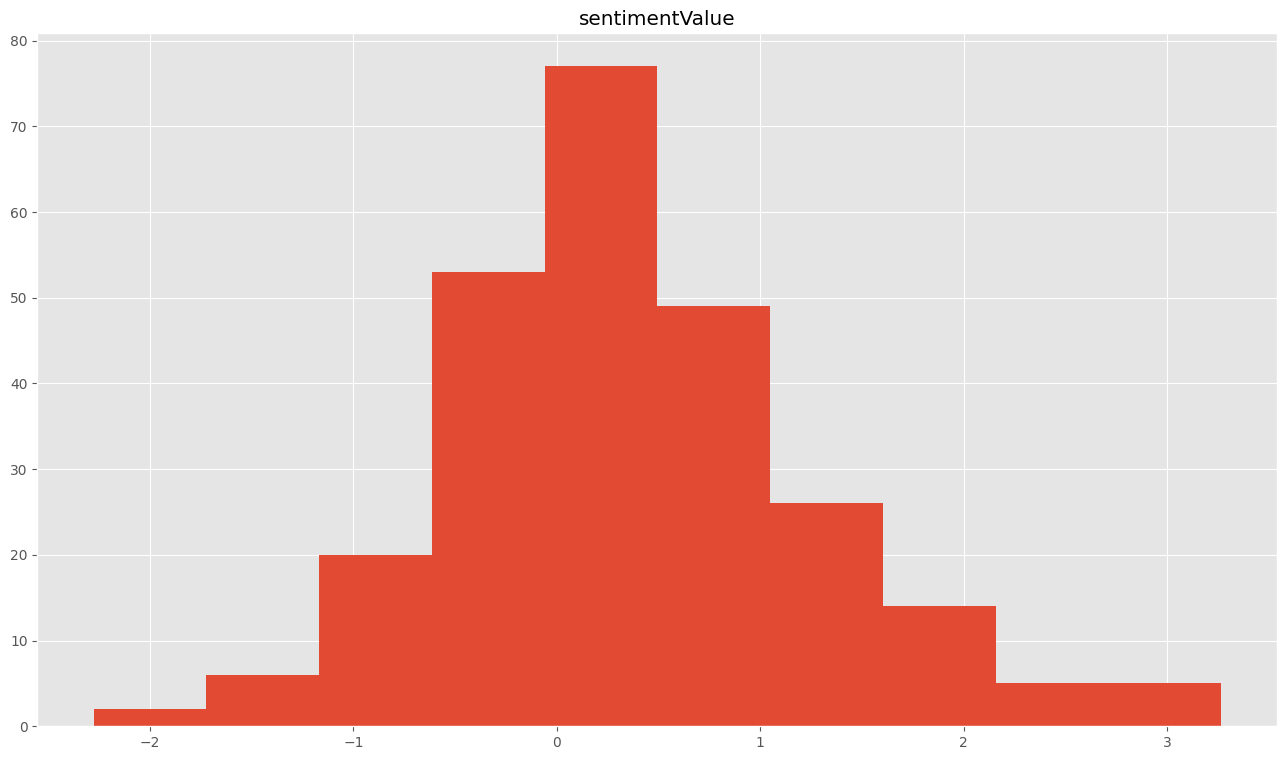

In [92]:
df.hist('sentimentValue')
plt.show()

<Axes: xlabel='Star Rating', ylabel='count'>

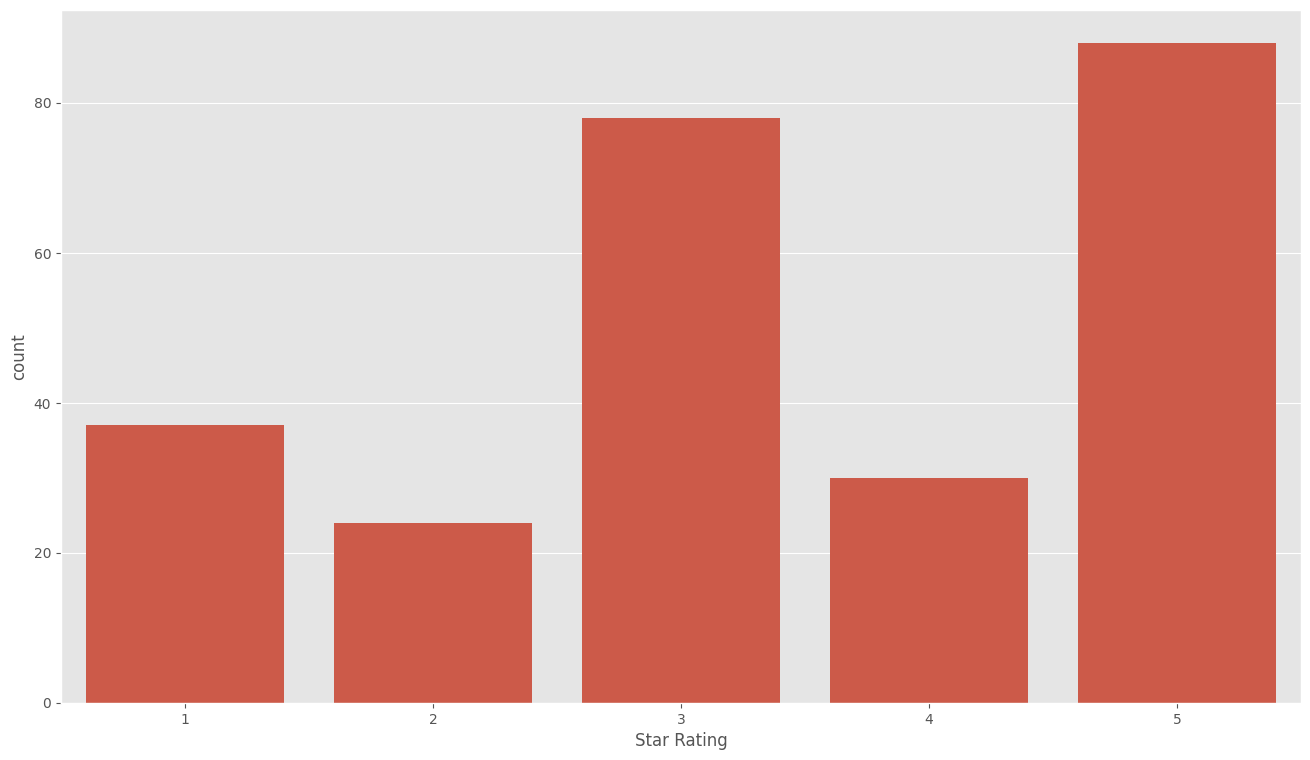

In [93]:
sb.countplot(x = "Star Rating", data = df)

<Axes: xlabel='wordcount', ylabel='count'>

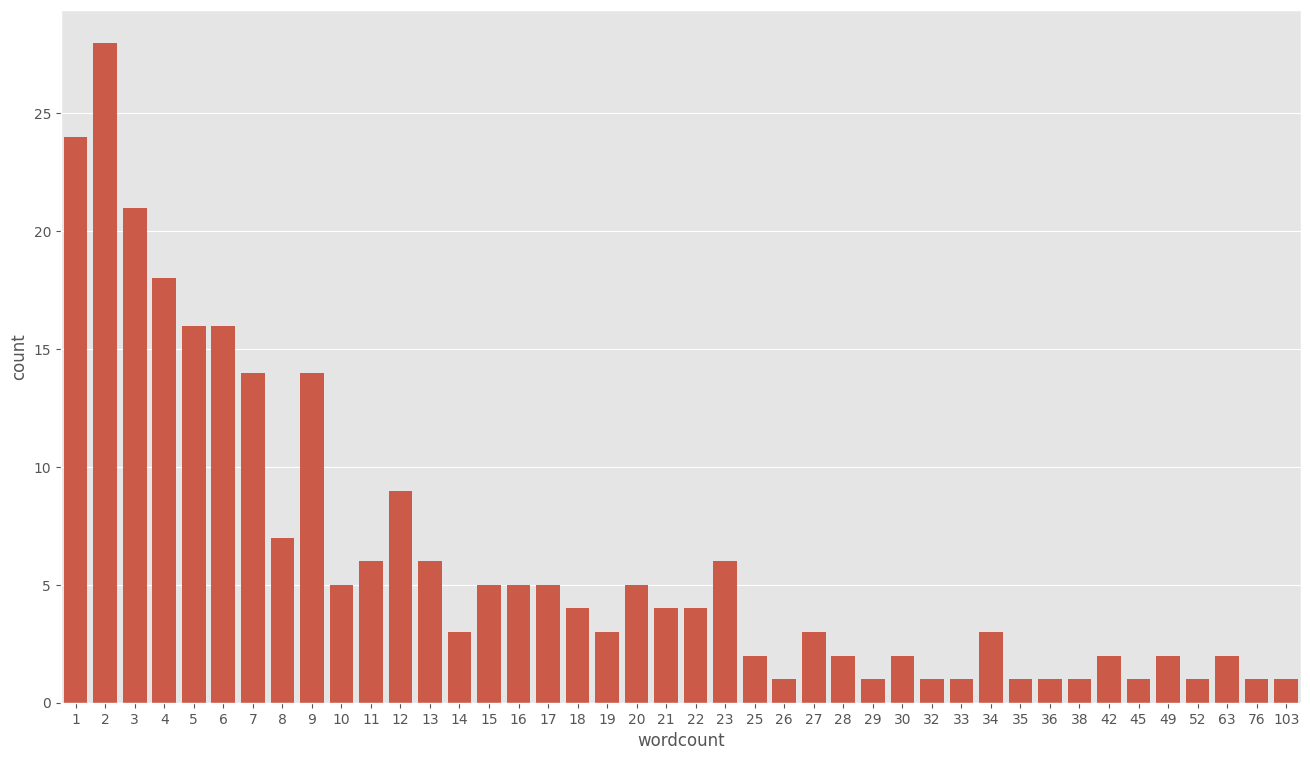

In [94]:
sb.countplot(x = "wordcount", data = df)

In [95]:
print(df.groupby("Star Rating").size())

Star Rating
1    37
2    24
3    78
4    30
5    88
dtype: int64


In [21]:
X = df[["wordcount","sentimentValue"]].values
y = df["Star Rating"].values

#Escalado y normalización a los datos

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# División de train-test simple y balanceado

## División de train y test simple

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## División de train y test con sobremuestreo

In [97]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state = 42)
X_balanceado, y_balanceado = oversampler.fit_resample(X,y)

#division train and test
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_balanceado, y_balanceado, test_size = 0.2, random_state = 42)

## División de train y test con submuestreo

In [98]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state = 42)
X_balanceado_2, y_balanceado_2 = undersampler.fit_resample(X,y)

#division train and test
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_balanceado_2, y_balanceado_2, test_size = 0.2, random_state = 42)

# Modelos Simples 

## Regresión Logística

In [99]:
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
for i in solver:
  modelo = LogisticRegression(solver = i).fit(X_train, y_train)
  pred = modelo.predict(X_test)
  print("-------------------------------------------")
  print("Modelo con el solver: ", i)
  print(f"Accuracy de entrenamiento: {modelo.score(X_train, y_train)}")
  print(f"Accuracy de test:{modelo.score(X_test, y_test)}")
  print(classification_report(y_test, pred))
  print("-------------------------------------------")

-------------------------------------------
Modelo con el solver:  lbfgs
Accuracy de entrenamiento: 0.6634146341463415
Accuracy de test:0.6346153846153846
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.67      1.00      0.80         2
           3       0.52      1.00      0.68        14
           4       0.00      0.00      0.00         7
           5       0.77      0.89      0.83        19

    accuracy                           0.63        52
   macro avg       0.39      0.58      0.46        52
weighted avg       0.45      0.63      0.52        52

-------------------------------------------
-------------------------------------------
Modelo con el solver:  liblinear
Accuracy de entrenamiento: 0.6585365853658537
Accuracy de test:0.6346153846153846
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       1.00      1.00      1.00 

/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python

## Árbol de Decisión

-------------------------------------------
Arbol realizado con el criterio:  gini
Accuracy de entrenamiento: 0.6390243902439025
Accuracy de test:0.6346153846153846
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.67      1.00      0.80         2
           3       0.52      1.00      0.68        14
           4       0.00      0.00      0.00         7
           5       0.77      0.89      0.83        19

    accuracy                           0.63        52
   macro avg       0.39      0.58      0.46        52
weighted avg       0.45      0.63      0.52        52

-------------------------------------------
-------------------------------------------
Arbol realizado con el criterio:  entropy
Accuracy de entrenamiento: 0.6390243902439025
Accuracy de test:0.6346153846153846
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.67  

/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python

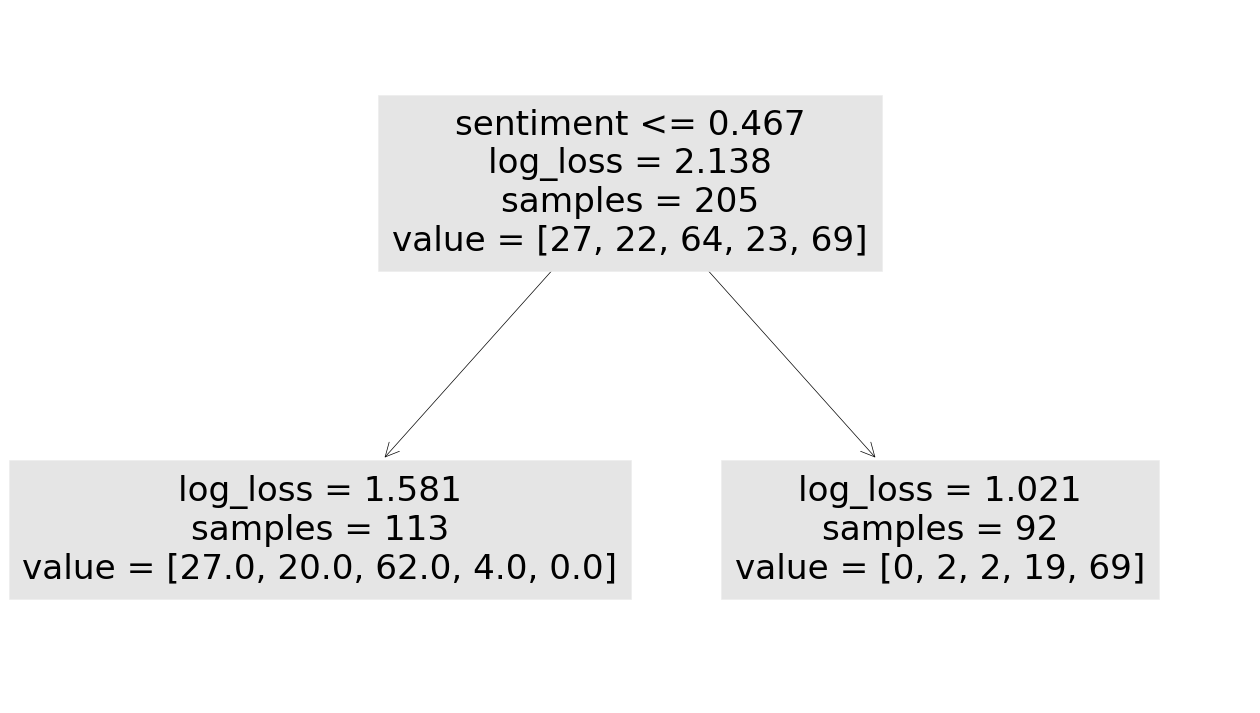

In [100]:
criterio = ['gini', 'entropy', 'log_loss']
for i in criterio:
  arbol = tree.DecisionTreeClassifier(criterion = i, max_depth = 1).fit(X_train, y_train)
  tree.plot_tree(arbol, feature_names = ["wordcount", "sentiment"])
  print("-------------------------------------------")
  print("Arbol realizado con el criterio: ", i)
  print(f"Accuracy de entrenamiento: {arbol.score(X_train, y_train)}")
  print(f"Accuracy de test:{arbol.score(X_test, y_test)}")
  print(classification_report(y_test, pred))
  print("-------------------------------------------")

## KNN

In [101]:
n_neighbors = [2,3,4,5,6]

for i in n_neighbors:
  knn=KNeighborsClassifier(n_neighbors = i)
  knn.fit(X_train, y_train)
  pred = knn.predict(X_test)
  print("-------------------------------------------")
  print(f"Métricas para {i} vecinos")
  print(f"Accuracy de entrenamiento: {knn.score(X_train, y_train)}")
  print(f"Accuracy de test: {knn.score(X_test, y_test)}")
  print(classification_report(y_test, pred))
  print("-------------------------------------------")

-------------------------------------------
Métricas para 2 vecinos
Accuracy de entrenamiento: 0.9219512195121952
Accuracy de test: 0.8461538461538461
              precision    recall  f1-score   support

           1       0.75      0.90      0.82        10
           2       0.40      1.00      0.57         2
           3       0.91      0.71      0.80        14
           4       0.86      0.86      0.86         7
           5       1.00      0.89      0.94        19

    accuracy                           0.85        52
   macro avg       0.78      0.87      0.80        52
weighted avg       0.89      0.85      0.86        52

-------------------------------------------
-------------------------------------------
Métricas para 3 vecinos
Accuracy de entrenamiento: 0.9414634146341463
Accuracy de test: 0.8461538461538461
              precision    recall  f1-score   support

           1       0.73      0.80      0.76        10
           2       0.40      1.00      0.57         2
  

In [102]:
algoritmo=['auto', 'ball_tree', 'kd_tree', 'brute']
for a in algoritmo:
  knn = KNeighborsClassifier(n_neighbors = 3, algorithm = a)
  knn.fit(X_train, y_train)
  pred = knn.predict(X_test)
  print("-------------------------------------------")
  print(f"Metricas para 3 vecinos usando el algoritmo: ", a)
  print(f"Acurracy de entrenamiento: {knn.score(X_train, y_train)}")
  print(f"Acurracy de test: {knn.score(X_test, y_test)}")
  print(classification_report(y_test, pred))
  print("-------------------------------------------")

-------------------------------------------
Metricas para 3 vecinos usando el algoritmo:  auto


Acurracy de entrenamiento: 0.9414634146341463
Acurracy de test: 0.8461538461538461
              precision    recall  f1-score   support

           1       0.73      0.80      0.76        10
           2       0.40      1.00      0.57         2
           3       1.00      0.79      0.88        14
           4       1.00      0.57      0.73         7
           5       0.90      1.00      0.95        19

    accuracy                           0.85        52
   macro avg       0.81      0.83      0.78        52
weighted avg       0.89      0.85      0.85        52

-------------------------------------------
-------------------------------------------
Metricas para 3 vecinos usando el algoritmo:  ball_tree
Acurracy de entrenamiento: 0.9414634146341463
Acurracy de test: 0.8461538461538461
              precision    recall  f1-score   support

           1       0.73      0.80      0.76        10
           2       0.40      1.00      0.57         2
           3       1.00      0.79     

## SVM

In [61]:
nucleo = ['linear', 'poly', 'rbf', 'sigmoid']
for k in nucleo:
  modelo = SVC(kernel = k).fit(X_train, y_train)
  pred = modelo.predict(X_test)
  print("-------------------------------------------")
  print("Modelo con el kernel: ", k)
  print(f"Accuracy de entrenamiento: {modelo.score(X_train, y_train)}")
  print(f"Acuracy de test: {modelo.score(X_test, y_test)}")
  print(classification_report(y_test, pred))
  print("-------------------------------------------")

-------------------------------------------
Modelo con el kernel:  linear
Accuracy de entrenamiento: 0.5902439024390244
Acuracy de test: 0.5961538461538461
              precision    recall  f1-score   support

           1       1.00      0.10      0.18        10
           2       1.00      1.00      1.00         2
           3       0.40      1.00      0.57        14
           4       0.00      0.00      0.00         7
           5       1.00      0.74      0.85        19

    accuracy                           0.60        52
   macro avg       0.68      0.57      0.52        52
weighted avg       0.70      0.60      0.54        52

-------------------------------------------
-------------------------------------------
Modelo con el kernel:  poly
Accuracy de entrenamiento: 0.8878048780487805
Acuracy de test: 0.8076923076923077
              precision    recall  f1-score   support

           1       0.90      0.90      0.90        10
           2       0.40      1.00      0.57     

/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python

# Modelos con Sobremuestreo

## Regresión Logística

In [103]:
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
for i in solver:
  modelo = LogisticRegression(solver = i).fit(X_train_1, y_train_1)
  pred = modelo.predict(X_test_1)
  print("-------------------------------------------")
  print("Modelo con el solver: ", i)
  print(f"Acurracy de entrenamiento: {modelo.score(X_train_1, y_train_1)}")
  print(f"Acurracy de test:{modelo.score(X_test_1, y_test_1)}")
  print(classification_report(y_test_1, pred))
  print("-------------------------------------------")

-------------------------------------------
Modelo con el solver:  lbfgs
Acurracy de entrenamiento: 0.8721590909090909
Acurracy de test:0.7159090909090909
              precision    recall  f1-score   support

           1       0.80      0.91      0.85        22
           2       0.50      1.00      0.67        11
           3       0.91      0.43      0.59        23
           4       0.89      0.47      0.62        17
           5       0.67      0.93      0.78        15

    accuracy                           0.72        88
   macro avg       0.75      0.75      0.70        88
weighted avg       0.79      0.72      0.70        88

-------------------------------------------
-------------------------------------------
Modelo con el solver:  liblinear
Acurracy de entrenamiento: 0.7414772727272727
Acurracy de test:0.6022727272727273
              precision    recall  f1-score   support

           1       0.73      0.86      0.79        22
           2       0.44      1.00      0.61 

## Árbol de Decisión

-------------------------------------------
Arbol realizado con el criterio:  gini
Acurracy de entrenamiento: 0.4090909090909091
Acurracy de test:0.2727272727272727
              precision    recall  f1-score   support

           1       0.80      0.91      0.85        22
           2       0.50      1.00      0.67        11
           3       0.91      0.43      0.59        23
           4       0.89      0.47      0.62        17
           5       0.67      0.93      0.78        15

    accuracy                           0.72        88
   macro avg       0.75      0.75      0.70        88
weighted avg       0.79      0.72      0.70        88

-------------------------------------------
-------------------------------------------
Arbol realizado con el criterio:  entropy
Acurracy de entrenamiento: 0.4119318181818182
Acurracy de test:0.2840909090909091
              precision    recall  f1-score   support

           1       0.80      0.91      0.85        22
           2       0.50  

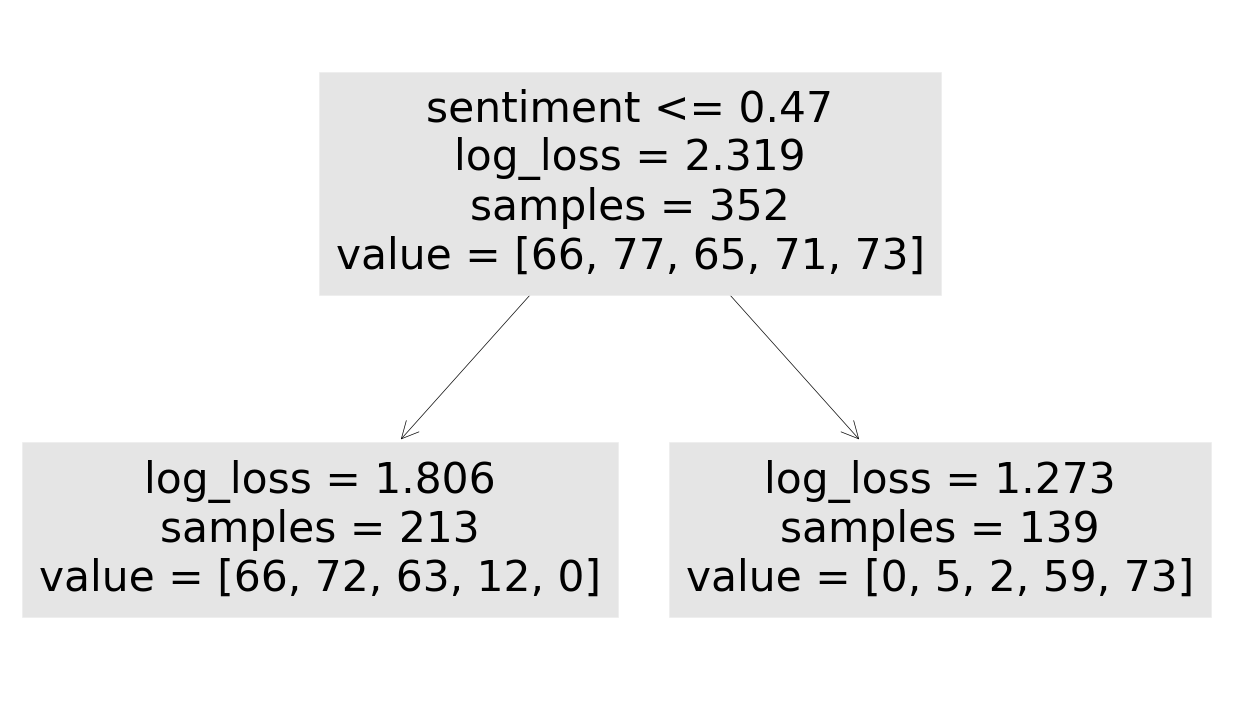

In [104]:
criterio = ['gini', 'entropy', 'log_loss']
for i in criterio:
  arbol = tree.DecisionTreeClassifier(criterion = i, max_depth= 1).fit(X_train_1, y_train_1)
  tree.plot_tree(arbol, feature_names = ["wordcount", "sentiment"])
  print("-------------------------------------------")
  print("Arbol realizado con el criterio: ", i)
  print(f"Acurracy de entrenamiento: {arbol.score(X_train_1, y_train_1)}")
  print(f"Acurracy de test:{arbol.score(X_test_1, y_test_1)}")
  print(classification_report(y_test_1, pred))
  print("-------------------------------------------")

## KNN

In [105]:
n_neighbors=[2,3,4,5,6]

for i in n_neighbors:
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(X_train_1, y_train_1)
  pred = knn.predict(X_test_1)
  print("-------------------------------------------")
  print(f"Metricas para {i} vecinos")
  print(f"Acurracy de entrenamiento: {knn.score(X_train_1, y_train_1)}")
  print(f"Acurracy de test: {knn.score(X_test_1, y_test_1)}")
  print(classification_report(y_test_1, pred))
  print("-------------------------------------------")

-------------------------------------------
Metricas para 2 vecinos
Acurracy de entrenamiento: 0.96875
Acurracy de test: 0.8863636363636364
              precision    recall  f1-score   support

           1       0.85      1.00      0.92        22
           2       0.79      1.00      0.88        11
           3       0.94      0.65      0.77        23
           4       0.89      1.00      0.94        17
           5       1.00      0.87      0.93        15

    accuracy                           0.89        88
   macro avg       0.89      0.90      0.89        88
weighted avg       0.90      0.89      0.88        88

-------------------------------------------
-------------------------------------------
Metricas para 3 vecinos
Acurracy de entrenamiento: 0.9630681818181818
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.84      0.95      0.89        22
           2       0.73      1.00      0.85        11
           3       1.00   

In [106]:
algoritmo = ['auto', 'ball_tree', 'kd_tree', 'brute']
for a in algoritmo:
  knn = KNeighborsClassifier(n_neighbors = 3, algorithm = a)
  knn.fit(X_train_1, y_train_1)
  pred = knn.predict(X_test_1)
  print("-------------------------------------------")
  print(f"Metricas para 2 vecinos usando el algoritmo: ", a)
  print(f"Acurracy de entrenamiento: {knn.score(X_train_1, y_train_1)}")
  print(f"Acurracy de test: {knn.score(X_test_1, y_test_1)}")
  print(classification_report(y_test_1, pred))
  print("-------------------------------------------")

-------------------------------------------
Metricas para 2 vecinos usando el algoritmo:  auto
Acurracy de entrenamiento: 0.9630681818181818
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.84      0.95      0.89        22
           2       0.73      1.00      0.85        11
           3       1.00      0.61      0.76        23
           4       0.89      1.00      0.94        17
           5       0.93      0.93      0.93        15

    accuracy                           0.88        88
   macro avg       0.88      0.90      0.87        88
weighted avg       0.89      0.88      0.87        88

-------------------------------------------


-------------------------------------------
Metricas para 2 vecinos usando el algoritmo:  ball_tree
Acurracy de entrenamiento: 0.9630681818181818
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.84      0.95      0.89        22
           2       0.73      1.00      0.85        11
           3       1.00      0.61      0.76        23
           4       0.89      1.00      0.94        17
           5       0.93      0.93      0.93        15

    accuracy                           0.88        88
   macro avg       0.88      0.90      0.87        88
weighted avg       0.89      0.88      0.87        88

-------------------------------------------
-------------------------------------------
Metricas para 2 vecinos usando el algoritmo:  kd_tree
Acurracy de entrenamiento: 0.9630681818181818
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.84      0.95      0.89        22
           2       0

## SVM

In [81]:
nucleo = ['linear', 'poly', 'rbf', 'sigmoid']
for k in nucleo:
  modelo = SVC(kernel = k).fit(X_train_1, y_train_1)
  pred = modelo.predict(X_test_1)
  print("-------------------------------------------")
  print("Modelo con el kernel: ", k)
  print(f"Acurracy de entrenamiento: {modelo.score(X_train_1, y_train_1)}")
  print(f"Acurracy de test: {modelo.score(X_test_1, y_test_1)}")
  print(classification_report(y_test_1, pred))
  print("-------------------------------------------")

-------------------------------------------
Modelo con el kernel:  linear
Acurracy de entrenamiento: 0.8153409090909091
Acurracy de test: 0.7386363636363636
              precision    recall  f1-score   support

           1       1.00      0.73      0.84        22
           2       0.59      0.91      0.71        11
           3       0.68      0.74      0.71        23
           4       0.76      0.76      0.76        17
           5       0.69      0.60      0.64        15

    accuracy                           0.74        88
   macro avg       0.75      0.75      0.73        88
weighted avg       0.77      0.74      0.74        88

-------------------------------------------
-------------------------------------------
Modelo con el kernel:  poly
Acurracy de entrenamiento: 0.8977272727272727
Acurracy de test: 0.8409090909090909
              precision    recall  f1-score   support

           1       0.91      0.95      0.93        22
           2       0.50      0.91      0.65   

/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Modelos con Submuestreo

## Regresión Logística



In [107]:
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
for i in solver:
  modelo = LogisticRegression(solver = i).fit(X_train_2, y_train_2)
  pred = modelo.predict(X_test_2)
  print("-------------------------------------------")
  print("Modelo con el solver: ", i)
  print(f"Acurracy de entrenamiento: {modelo.score(X_train_2, y_train_2)}")
  print(f"Acurracy de test:{modelo.score(X_test_2, y_test_2)}")
  print(classification_report(y_test_2, pred))
  print("-------------------------------------------")

-------------------------------------------
Modelo con el solver:  lbfgs
Acurracy de entrenamiento: 0.6875
Acurracy de test:0.625
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       0.83      0.71      0.77         7
           3       0.00      0.00      0.00         5
           4       0.40      0.50      0.44         4
           5       0.50      1.00      0.67         3

    accuracy                           0.62        24
   macro avg       0.49      0.64      0.54        24
weighted avg       0.52      0.62      0.56        24

-------------------------------------------
-------------------------------------------
Modelo con el solver:  liblinear
Acurracy de entrenamiento: 0.6041666666666666
Acurracy de test:0.625
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         5
           2       0.83      0.71      0.77         7
           3       0.00     

/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python

## Árbol de Decisión

-------------------------------------------
Arbol realizado con el criterio:  gini
Acurracy de entrenamiento: 0.4166666666666667
Acurracy de test:0.3333333333333333
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       0.83      0.71      0.77         7
           3       0.00      0.00      0.00         5
           4       0.40      0.50      0.44         4
           5       0.50      1.00      0.67         3

    accuracy                           0.62        24
   macro avg       0.49      0.64      0.54        24
weighted avg       0.52      0.62      0.56        24

-------------------------------------------
-------------------------------------------
Arbol realizado con el criterio:  entropy
Acurracy de entrenamiento: 0.4166666666666667
Acurracy de test:0.3333333333333333
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       0.83  

/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python

              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       0.83      0.71      0.77         7
           3       0.00      0.00      0.00         5
           4       0.40      0.50      0.44         4
           5       0.50      1.00      0.67         3

    accuracy                           0.62        24
   macro avg       0.49      0.64      0.54        24
weighted avg       0.52      0.62      0.56        24

-------------------------------------------


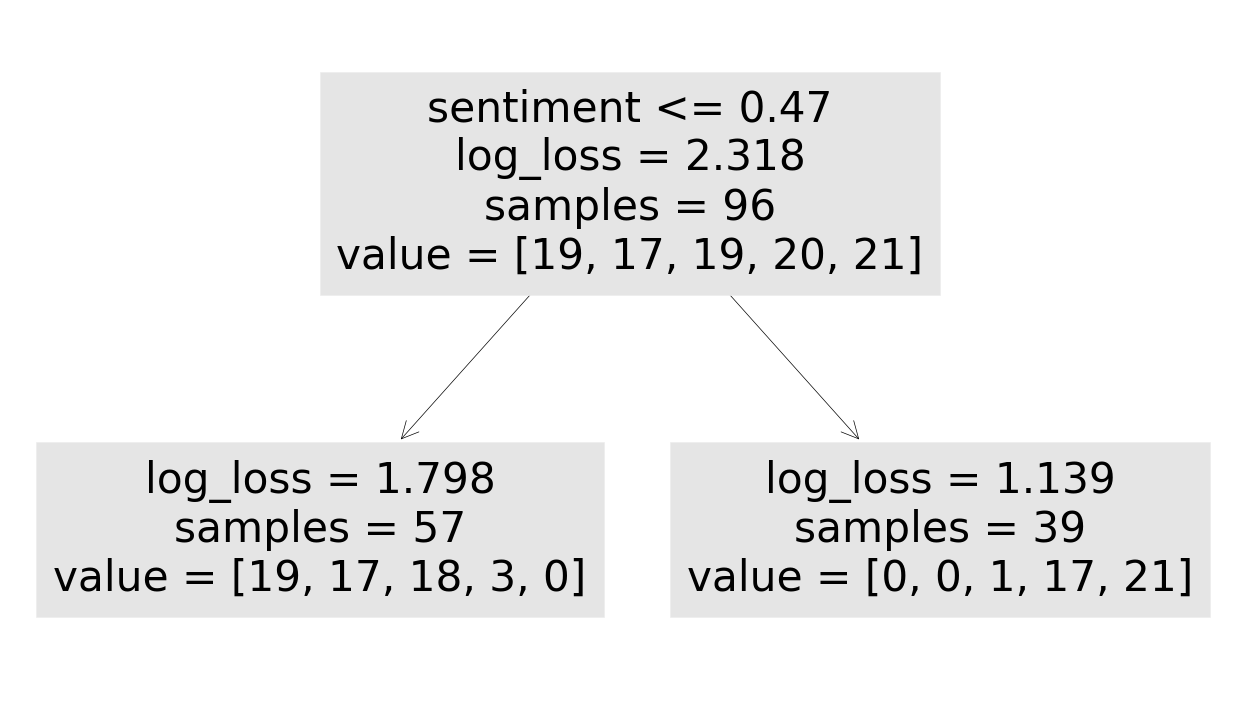

In [108]:
criterio = ['gini', 'entropy', 'log_loss']
for i in criterio:
  arbol = tree.DecisionTreeClassifier(criterion = i, max_depth = 1).fit(X_train_2, y_train_2)
  tree.plot_tree(arbol, feature_names = ["wordcount", "sentiment"])
  print("-------------------------------------------")
  print("Arbol realizado con el criterio: ", i)
  print(f"Acurracy de entrenamiento: {arbol.score(X_train_2, y_train_2)}")
  print(f"Acurracy de test:{arbol.score(X_test_2, y_test_2)}")
  print(classification_report(y_test_2, pred))
  print("-------------------------------------------")

## KNN

In [109]:
n_neighbors=[2,3,4,5,6]

for i in n_neighbors:
  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(X_train_2, y_train_2)
  pred = knn.predict(X_test_2)
  print("-------------------------------------------")
  print(f"Metricas para {i} vecinos")
  print(f"Acurracy de entrenamiento: {knn.score(X_train_2, y_train_2)}")
  print(f"Acurracy de test: {knn.score(X_test_2, y_test_2)}")
  print(classification_report(y_test_2, pred))
  print("-------------------------------------------")

-------------------------------------------
Metricas para 2 vecinos
Acurracy de entrenamiento: 0.8645833333333334
Acurracy de test: 0.8333333333333334
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       1.00      0.86      0.92         7
           3       0.80      0.80      0.80         5
           4       0.80      1.00      0.89         4
           5       1.00      0.33      0.50         3

    accuracy                           0.83        24
   macro avg       0.86      0.80      0.79        24
weighted avg       0.87      0.83      0.82        24

-------------------------------------------
-------------------------------------------
Metricas para 3 vecinos
Acurracy de entrenamiento: 0.84375
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       1.00      0.86      0.92         7
           3       1.00   

In [110]:
algoritmo = ['auto', 'ball_tree', 'kd_tree', 'brute']
for a in algoritmo:
  knn = KNeighborsClassifier(n_neighbors = 3, algorithm = a)
  knn.fit(X_train_2, y_train_2)
  pred = knn.predict(X_test_2)
  print("-------------------------------------------")
  print(f"Metricas para 2 vecinos usando el algoritmo: ", a)
  print(f"Acurracy de entrenamiento: {knn.score(X_train_2, y_train_2)}")
  print(f"Acurracy de test: {knn.score(X_test_2, y_test_2)}")
  print(classification_report(y_test_2, pred))
  print("-------------------------------------------")

-------------------------------------------
Metricas para 2 vecinos usando el algoritmo:  auto
Acurracy de entrenamiento: 0.84375
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       1.00      0.86      0.92         7
           3       1.00      0.80      0.89         5
           4       0.80      1.00      0.89         4
           5       1.00      0.67      0.80         3

    accuracy                           0.88        24
   macro avg       0.90      0.86      0.87        24
weighted avg       0.91      0.88      0.88        24

-------------------------------------------
-------------------------------------------
Metricas para 2 vecinos usando el algoritmo:  ball_tree
Acurracy de entrenamiento: 0.84375
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       1.00      0.86      0.92  

-------------------------------------------
Metricas para 2 vecinos usando el algoritmo:  kd_tree
Acurracy de entrenamiento: 0.84375
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       1.00      0.86      0.92         7
           3       1.00      0.80      0.89         5
           4       0.80      1.00      0.89         4
           5       1.00      0.67      0.80         3

    accuracy                           0.88        24
   macro avg       0.90      0.86      0.87        24
weighted avg       0.91      0.88      0.88        24

-------------------------------------------
-------------------------------------------
Metricas para 2 vecinos usando el algoritmo:  brute
Acurracy de entrenamiento: 0.84375
Acurracy de test: 0.875
              precision    recall  f1-score   support

           1       0.71      1.00      0.83         5
           2       1.00      0.86      0.92   

## SVM

In [80]:
nucleo = ['linear', 'poly', 'rbf', 'sigmoid']
for k in nucleo:
  modelo = SVC(kernel = k).fit(X_train_2, y_train_2)
  pred = modelo.predict(X_test_2)
  print("-------------------------------------------")
  print("Modelo con el kernel: ", k)
  print(f"Acurracy de entrenamiento: {modelo.score(X_train_2, y_train_2)}")
  print(f"Acurracy de test: {modelo.score(X_test_2, y_test_2)}")
  print(classification_report(y_test_2, pred))
  print("-------------------------------------------")

-------------------------------------------
Modelo con el kernel:  linear
Acurracy de entrenamiento: 0.46875
Acurracy de test: 0.4583333333333333
              precision    recall  f1-score   support

           1       0.62      1.00      0.77         5
           2       1.00      0.43      0.60         7
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         4
           5       0.33      1.00      0.50         3

    accuracy                           0.46        24
   macro avg       0.39      0.49      0.37        24
weighted avg       0.46      0.46      0.40        24

-------------------------------------------
-------------------------------------------
Modelo con el kernel:  poly
Acurracy de entrenamiento: 0.8541666666666666
Acurracy de test: 0.7916666666666666
              precision    recall  f1-score   support

           1       0.83      1.00      0.91         5
           2       0.83      0.71      0.77         7
   

/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/byob/.local/lib/python

# Validación cruzada (Cross-Validation)

## Regresión Logística

In [113]:
modelo = LogisticRegression()

cv_puntajes = cross_val_score(modelo, X_train, y_train, cv = cv)

cv_predicciones = cross_val_predict(modelo, X_test, y_test, cv = cv)

print(f"Accuracy promedio= {cv_puntajes.mean()}")

Accuracy promedio= 0.6536585365853659


/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


## Árbol de Decisión

In [114]:
criterio = ['gini', 'entropy', 'log_loss']
for i in criterio:
  print("-------------------------------------------")
  print("Accuracy con: ", i)
  modelo = tree.DecisionTreeClassifier(criterion = i, max_depth = 1).fit(X_train_2, y_train_2)
  cv_puntajes = cross_val_score(modelo, X_train, y_train, cv = cv)
  cv_predicciones=cross_val_predict(modelo, X_test, y_test, cv = cv)
  print(f"Accuracy promedio= {cv_puntajes.mean()}")
  print("-------------------------------------------")

-------------------------------------------
Accuracy con:  gini
Accuracy promedio= 0.6341463414634146
-------------------------------------------
-------------------------------------------
Accuracy con:  entropy
Accuracy promedio= 0.6341463414634146
-------------------------------------------
-------------------------------------------
Accuracy con:  log_loss
Accuracy promedio= 0.6341463414634146
-------------------------------------------


/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


## KNN

In [115]:
algoritmo = ['auto', 'ball_tree', 'kd_tree', 'brute']
for a in algoritmo:
  print("-------------------------------------------")
  modelo = KNeighborsClassifier(n_neighbors = 3, algorithm = a)
  print("Accuracy con: ", a)
  cv_puntajes = cross_val_score(modelo, X_train, y_train, cv = cv)
  cv_predicciones = cross_val_predict(modelo, X_test, y_test,cv = cv)
  print(f"Accuracy promedio= {cv_puntajes.mean()}")
  print("-------------------------------------------")

-------------------------------------------
Accuracy con:  auto
Accuracy promedio= 0.8682926829268294
-------------------------------------------
-------------------------------------------
Accuracy con:  ball_tree
Accuracy promedio= 0.8682926829268294
-------------------------------------------
-------------------------------------------
Accuracy con:  kd_tree


/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Accuracy promedio= 0.8682926829268294
-------------------------------------------
-------------------------------------------
Accuracy con:  brute
Accuracy promedio= 0.8682926829268294
-------------------------------------------


## SVM

In [116]:
nucleo = ['linear', 'poly', 'rbf', 'sigmoid']
for k in nucleo:
  print("-------------------------------------------")
  modelo = SVC(kernel = k)
  print("Accuracy con: ", k)
  cv_puntajes = cross_val_score(modelo, X_train, y_train, cv = cv)
  cv_predicciones = cross_val_predict(modelo, X_test, y_test, cv = cv)
  print(f"Accuracy promedio= {cv_puntajes.mean()}")
  print("-------------------------------------------")

-------------------------------------------
Accuracy con:  linear
Accuracy promedio= 0.551219512195122
-------------------------------------------
-------------------------------------------
Accuracy con:  poly
Accuracy promedio= 0.8829268292682928
-------------------------------------------
-------------------------------------------
Accuracy con:  rbf
Accuracy promedio= 0.8195121951219513
-------------------------------------------
-------------------------------------------
Accuracy con:  sigmoid


/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/byob/.local/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Accuracy promedio= 0.16097560975609757
-------------------------------------------
